# <font color=#0099CC>**Notebook 5: Comparativa, Métricas y Monte Carlo**</font>

En este notebook se cierra el análisis del backtesting con:

1. **Cuadro de métricas** comparativo (CAGR, Volatilidad, Sharpe, Sortino, Máx. Drawdown, Beta y Alpha) de la estrategia Momentum frente al SPY buy & hold.
2. **Visualizaciones**: evolución de la rentabilidad acumulada (%), histograma de retornos mensuales (algoritmo vs SPY) y scatter de rentabilidades anuales y trimestrales (algoritmo vs SPY).
3. **Test de Monte Carlo** con 30 millones de "monos" (estrategias aleatorias), coste de rebalanceo 0,23 % × 2 por mes y tiempo de ejecución impreso.
4. **Análisis crítico**: impacto de la comisión mínima, robustez, sesgo de supervivencia, look-ahead y overfitting.

In [215]:
# Librerías
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Permite importar utilidades compartidas desde la raíz del proyecto
project_root = Path.cwd().resolve()
if not (project_root / 'notebook_utils.py').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from notebook_utils import configure_notebook_display, get_project_paths

# Configuración de visualización
configure_notebook_display(max_columns=None, max_rows=200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Parámetros del backtest
INITIAL_CAPITAL = 250_000.0
TRADING_DAYS_PER_YEAR = 252
MONTHS_PER_YEAR = 12

# Rutas de entrada / salida centralizadas
PATHS = get_project_paths(project_root)
OUTPUTS_DIR = PATHS.outputs
DATASETS_DIR = PATHS.datasets

> <u>Nota</u>: Se reutiliza `notebook_utils.py` para mantener una arquitectura consistente en el pipeline completo. Además, las funciones de métricas y los bloques analíticos mantienen un estilo uniforme y legible para facilitar revisión técnica y cumplimiento de buenas prácticas (PEP 8).

## <font color=#0099CC>**1. CARGA DE DATOS Y RETORNOS**</font>

Se cargan las series de equity diarias de la estrategia y del benchmark (generadas en el Notebook 4) y se calculan retornos diarios y mensuales para métricas, histogramas y Monte Carlo.

In [216]:
# Carga de series de equity diarias y preparación de retornos

portfolio_df = pd.read_csv(OUTPUTS_DIR / 'portfolio_daily_equity.csv', parse_dates=['date']).set_index('date')
benchmark_df = pd.read_csv(OUTPUTS_DIR / 'benchmark_daily_equity.csv', parse_dates=['date']).set_index('date')

# Equity diaria de la estrategia y del SPY
algo_equity = portfolio_df['equity']
spy_equity = benchmark_df['spy_equity']

# Retornos diarios
algo_ret_daily = algo_equity.pct_change().dropna()
spy_ret_daily = spy_equity.pct_change().dropna()

# Retornos mensuales (para histogramas y Monte Carlo)
algo_ret_monthly = algo_equity.resample('ME').last().pct_change().dropna()
spy_ret_monthly = spy_equity.resample('ME').last().pct_change().dropna()

print('> Datos cargados y retornos calculados:')
print(f"  - Días: {len(algo_ret_daily)}")
print(f"  - Meses: {len(algo_ret_monthly)}")

> Datos cargados y retornos calculados:
  - Días: 2785
  - Meses: 132


## <font color=#0099CC>**2. FUNCIONES DE MÉTRICAS**</font>

Definición de CAGR, volatilidad anualizada, Sharpe, Sortino, máximo drawdown y Beta/Alpha frente al benchmark, utilizadas en el cuadro comparativo.

In [217]:
# Funciones de métricas

def compute_cagr(equity: pd.Series) -> float:
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    return (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1


def compute_volatility(ret: pd.Series, freq: str = 'daily') -> float:
    if freq == 'daily':
        return ret.std(ddof=0) * np.sqrt(TRADING_DAYS_PER_YEAR)
    elif freq == 'monthly':
        return ret.std(ddof=0) * np.sqrt(MONTHS_PER_YEAR)
    else:
        raise ValueError('freq debe ser daily o monthly')


def compute_sharpe(ret: pd.Series, freq: str = 'daily', rf: float = 0.0) -> float:
    excess = ret - rf / (TRADING_DAYS_PER_YEAR if freq == 'daily' else MONTHS_PER_YEAR)
    vol = compute_volatility(excess, freq=freq)
    if vol == 0 or np.isnan(vol):
        return np.nan
    mean = excess.mean() * (TRADING_DAYS_PER_YEAR if freq == 'daily' else MONTHS_PER_YEAR)
    return mean / vol


def compute_sortino(ret: pd.Series, freq: str = 'daily', rf: float = 0.0) -> float:
    excess = ret - rf / (TRADING_DAYS_PER_YEAR if freq == 'daily' else MONTHS_PER_YEAR)
    downside = excess[excess < 0]
    if downside.empty:
        return np.nan
    if freq == 'daily':
        downside_vol = downside.std(ddof=0) * np.sqrt(TRADING_DAYS_PER_YEAR)
        ann_mean = excess.mean() * TRADING_DAYS_PER_YEAR
    else:
        downside_vol = downside.std(ddof=0) * np.sqrt(MONTHS_PER_YEAR)
        ann_mean = excess.mean() * MONTHS_PER_YEAR
    if downside_vol == 0 or np.isnan(downside_vol):
        return np.nan
    return ann_mean / downside_vol


def compute_max_drawdown(equity: pd.Series) -> float:
    cum_max = equity.cummax()
    dd = equity / cum_max - 1.0
    return dd.min()


def compute_beta_alpha(ret_algo: pd.Series, ret_bench: pd.Series, freq: str = 'daily'):
    # Alinear
    df = pd.concat([ret_algo, ret_bench], axis=1, join='inner').dropna()
    df.columns = ['algo', 'bench']
    cov = np.cov(df['algo'], df['bench'], ddof=0)
    var_b = cov[1, 1]
    if var_b == 0:
        return np.nan, np.nan
    beta = cov[0, 1] / var_b

    if freq == 'daily':
        factor = TRADING_DAYS_PER_YEAR
    else:
        factor = MONTHS_PER_YEAR

    mean_algo = df['algo'].mean() * factor
    mean_bench = df['bench'].mean() * factor
    alpha = mean_algo - beta * mean_bench
    return beta, alpha

## <font color=#0099CC>**3. CUADRO DE MÉTRICAS COMPARATIVO**</font>

Se calculan y muestran las métricas para la estrategia Momentum y para el SPY buy & hold (benchmark).

In [218]:
# Cuadro de métricas comparativo (estrategia vs SPY)

metrics = []

cagr_algo = compute_cagr(algo_equity)
vol_algo = compute_volatility(algo_ret_daily, freq='daily')
sharpe_algo = compute_sharpe(algo_ret_daily, freq='daily')
sortino_algo = compute_sortino(algo_ret_daily, freq='daily')
maxdd_algo = compute_max_drawdown(algo_equity)
beta_algo, alpha_algo = compute_beta_alpha(algo_ret_daily, spy_ret_daily, freq='daily')

metrics.append({
    'Estrategia': 'Momentum',
    'CAGR': cagr_algo,
    'Volatilidad': vol_algo,
    'Sharpe': sharpe_algo,
    'Sortino': sortino_algo,
    'Max Drawdown': maxdd_algo,
    'Beta vs SPY': beta_algo,
    'Alpha vs SPY': alpha_algo,
})

cagr_spy = compute_cagr(spy_equity)
vol_spy = compute_volatility(spy_ret_daily, freq='daily')
sharpe_spy = compute_sharpe(spy_ret_daily, freq='daily')
sortino_spy = compute_sortino(spy_ret_daily, freq='daily')
maxdd_spy = compute_max_drawdown(spy_equity)

metrics.append({
    'Estrategia': 'SPY buy & hold',
    'CAGR': cagr_spy,
    'Volatilidad': vol_spy,
    'Sharpe': sharpe_spy,
    'Sortino': sortino_spy,
    'Max Drawdown': maxdd_spy,
    'Beta vs SPY': 1.0,
    'Alpha vs SPY': 0.0,
})

metrics_df = pd.DataFrame(metrics).set_index('Estrategia')

print('> Cuadro de métricas:')
display(metrics_df)

metrics_df.to_csv(OUTPUTS_DIR / 'metrics_comparativa.csv')

> Cuadro de métricas:


,CAGR,Volatilidad,Sharpe,Sortino,Max Drawdown,Beta vs SPY,Alpha vs SPY
Estrategia,,,,,,,
Momentum,0.042160,0.248696,0.291615,0.362247,-0.554557,1.066998,-0.079839
SPY buy & hold,0.135053,0.177453,0.804698,0.978719,-0.337173,1.000000,0.000000


> <u>Comentario</u>:  La comparación de métricas muestra una inferioridad clara de la estrategia Momentum frente al SPY en este periodo.
>
> - <u>Rentabilidad</u>: El CAGR de Momentum (4.22%) queda muy por debajo del SPY (13.51%), por lo que el crecimiento del capital es sustancialmente menor.
>
> - <u>Riesgo total y a la baja</u>: Momentum asume más riesgo (volatilidad 24.87% vs 17.75%) y además sufre caídas más profundas (Max Drawdown -55.46% vs -33.72%), con peor experiencia de pérdida.
>
> - <u>Rentabilidad ajustada al riesgo</u>: Tanto Sharpe (0.29 vs 0.80) como Sortino (0.36 vs 0.98) confirman que Momentum compensa peor el riesgo asumido, especialmente el riesgo bajista.
>
> - <u>Exposición al mercado y generación de valor</u>: La estrategia tiene beta 1.07, es decir, una sensibilidad al mercado ligeramente superior al benchmark, pero con alpha -7.98%, lo que indica destrucción de valor relativo tras ajustar por esa exposición.
>
> En conjunto, la evidencia apunta a que, con esta parametrización y costes, la estrategia Momentum no supera al benchmark ni en retorno absoluto ni en perfil riesgo-retorno.

## <font color=#0099CC>**4. VISUALIZACIONES**</font>

### <font color=#336699>**4.1. Rentabilidad acumulada, histogramas mensuales y scatter anual/trimestral**</font>

A continuación se representa:
1) La evolución de la rentabilidad acumulada (%) del algoritmo frente al SPY
2) El histograma de retornos mensuales de la estrategia vs benchmark
3) El scatter de rentabilidades anuales y trimestrales (eje X: SPY, eje Y: algoritmo) para analizar recurrencia y correlación.

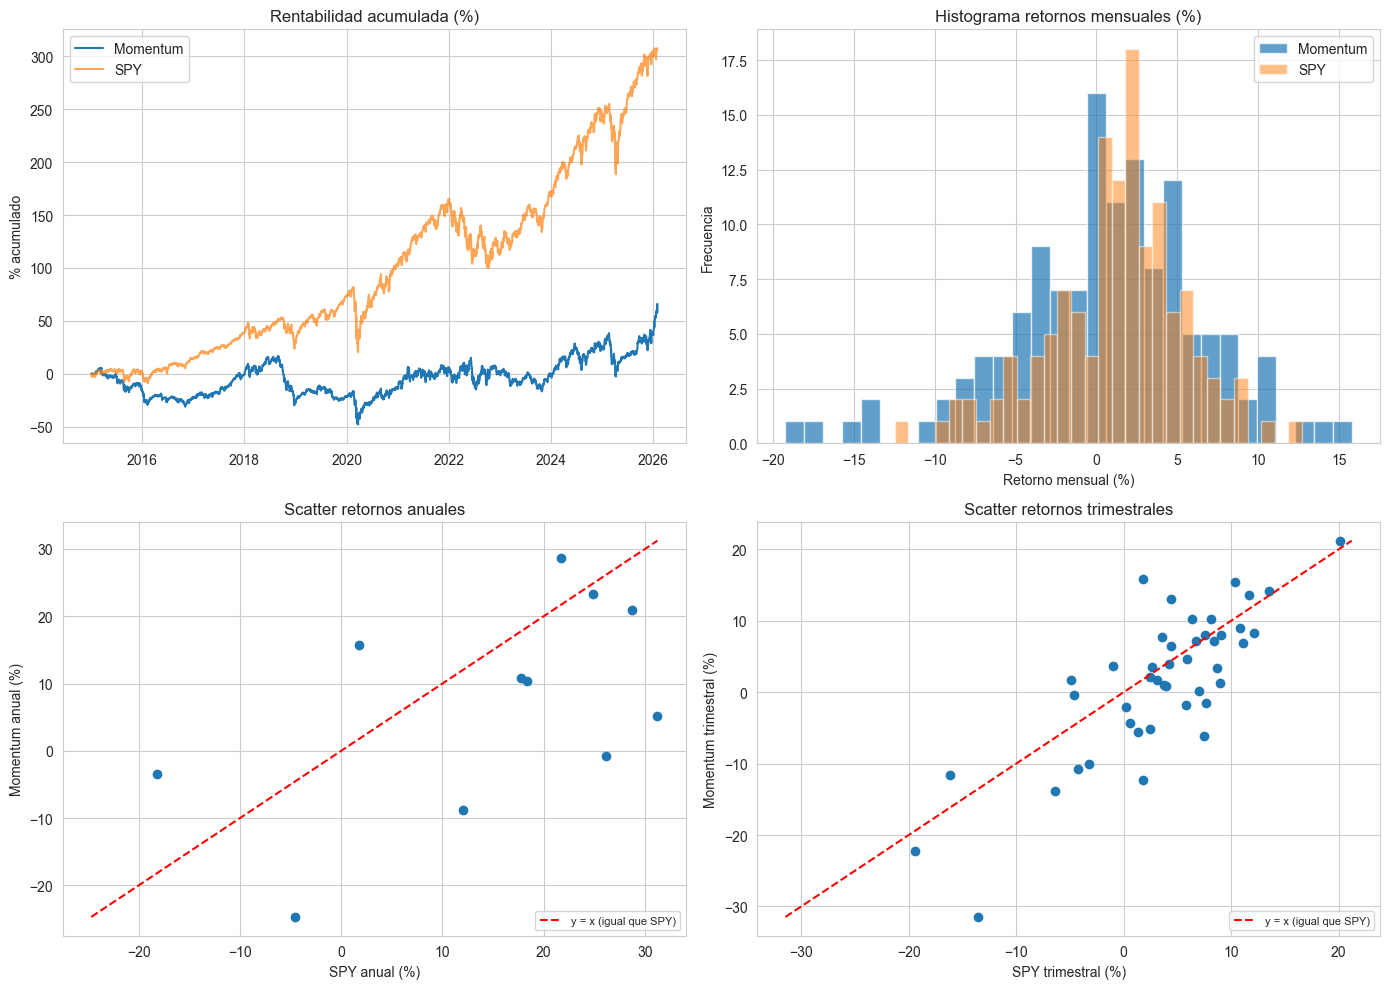

In [219]:
# Visualizaciones: equity acumulada y histogramas mensuales

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4.1 Equity acumulada (%)
ret_algo_cum = algo_equity / algo_equity.iloc[0] - 1.0
ret_spy_cum = spy_equity / spy_equity.iloc[0] - 1.0

axes[0, 0].plot(ret_algo_cum.index, 100 * ret_algo_cum, label='Momentum')
axes[0, 0].plot(ret_spy_cum.index, 100 * ret_spy_cum, label='SPY', alpha=0.7)
axes[0, 0].set_title('Rentabilidad acumulada (%)')
axes[0, 0].set_ylabel('% acumulado')
axes[0, 0].legend()

# 4.2 Histograma de retornos mensuales (Estrategia)
axes[0, 1].hist(100 * algo_ret_monthly, bins=30, alpha=0.7, label='Momentum')
axes[0, 1].hist(100 * spy_ret_monthly, bins=30, alpha=0.5, label='SPY')
axes[0, 1].set_title('Histograma retornos mensuales (%)')
axes[0, 1].set_xlabel('Retorno mensual (%)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].legend()

# 4.3 Scatter anual Momentum vs SPY
algo_ret_yearly = algo_equity.resample('YE').last().pct_change().dropna()
spy_ret_yearly = spy_equity.resample('YE').last().pct_change().dropna()

common_years = algo_ret_yearly.index.intersection(spy_ret_yearly.index)
x_anual = 100 * spy_ret_yearly.loc[common_years]
y_anual = 100 * algo_ret_yearly.loc[common_years]
axes[1, 0].scatter(x_anual, y_anual)
lim_anual = (min(x_anual.min(), y_anual.min()), max(x_anual.max(), y_anual.max()))
axes[1, 0].plot(lim_anual, lim_anual, 'r--', lw=1.5, label='y = x (igual que SPY)')
axes[1, 0].set_xlabel('SPY anual (%)')
axes[1, 0].set_ylabel('Momentum anual (%)')
axes[1, 0].set_title('Scatter retornos anuales')
axes[1, 0].legend(loc='lower right', fontsize=8)

# 4.4 Scatter trimestral Momentum vs SPY
algo_ret_quarterly = algo_equity.resample('QE').last().pct_change().dropna()
spy_ret_quarterly = spy_equity.resample('QE').last().pct_change().dropna()

common_q = algo_ret_quarterly.index.intersection(spy_ret_quarterly.index)
x_trim = 100 * spy_ret_quarterly.loc[common_q]
y_trim = 100 * algo_ret_quarterly.loc[common_q]
axes[1, 1].scatter(x_trim, y_trim)
lim_trim = (min(x_trim.min(), y_trim.min()), max(x_trim.max(), y_trim.max()))
axes[1, 1].plot(lim_trim, lim_trim, 'r--', lw=1.5, label='y = x (igual que SPY)')
axes[1, 1].set_xlabel('SPY trimestral (%)')
axes[1, 1].set_ylabel('Momentum trimestral (%)')
axes[1, 1].set_title('Scatter retornos trimestrales')
axes[1, 1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

><u>Comentario</u>:
>
>- <u>Rentabilidad acumulada</u>: Resumen de la evolución en % del capital de la estrategia y del SPY a lo largo del backtest (ya mostrada en el Notebook 4). El SPY supera claramente a la estrategia Momentum en rentabilidad acumulada en este periodo.
>
>- <u>Histograma de retornos mensuales (%)</u>: Muestra la distribución de frecuencia de los retornos mensuales de ambas series. El SPY concentra más masa en retornos positivos (pico en torno a 2,5–5 %) y presenta menos cola negativa extrema. La estrategia Momentum tiene una dispersión mayor: más observaciones de retornos muy negativos (hasta casi –20 % mensuales), lo que refleja su mayor volatilidad y riesgo a la baja, coherente con el mayor drawdown y el menor Sortino del cuadro de métricas.
>
>- <u>Scatter de retornos anuales</u>: Cada punto es un año (eje X: retorno anual del SPY, eje Y: retorno anual del algoritmo). La diagonal roja (y = x) marca "igual que el benchmark"; por encima, el algoritmo gana ese año; por debajo, pierde. La mayoría de los puntos quedan bajo la diagonal, indicando que en la mayor parte de los años la estrategia Momentum ha rentado menos que el SPY; solo en algunos años supera al benchmark. Refuerza la idea de underperformance recurrente a frecuencia anual.
>
>- <u>Scatter de retornos trimestrales</u>: Misma lógica que el anual pero con un punto por trimestre (más puntos, ~40). También aquí predominan los puntos bajo la diagonal: en muchos trimestres el algoritmo ha tenido menor retorno que el SPY, con episodios de fuerte underperformance (p. ej. trimestres en que el SPY es positivo y Momentum negativo, o Momentum con caídas mayores). El análisis de recurrencia a ambas frecuencias (anual y trimestral) confirma que la ventaja no ha sido sistemática frente al benchmark en este horizonte.

### <font color=#336699>**4.2. Retornos acumulados y drawdown**</font>

A continuación se estudian los retornos acumulados en base 1 con la zona de drawdown sombreada (desde el máximo histórico) y la zona por debajo del capital inicial (base 1) en naranja. Complementa la métrica Max Drawdown del cuadro del apartado anterior.

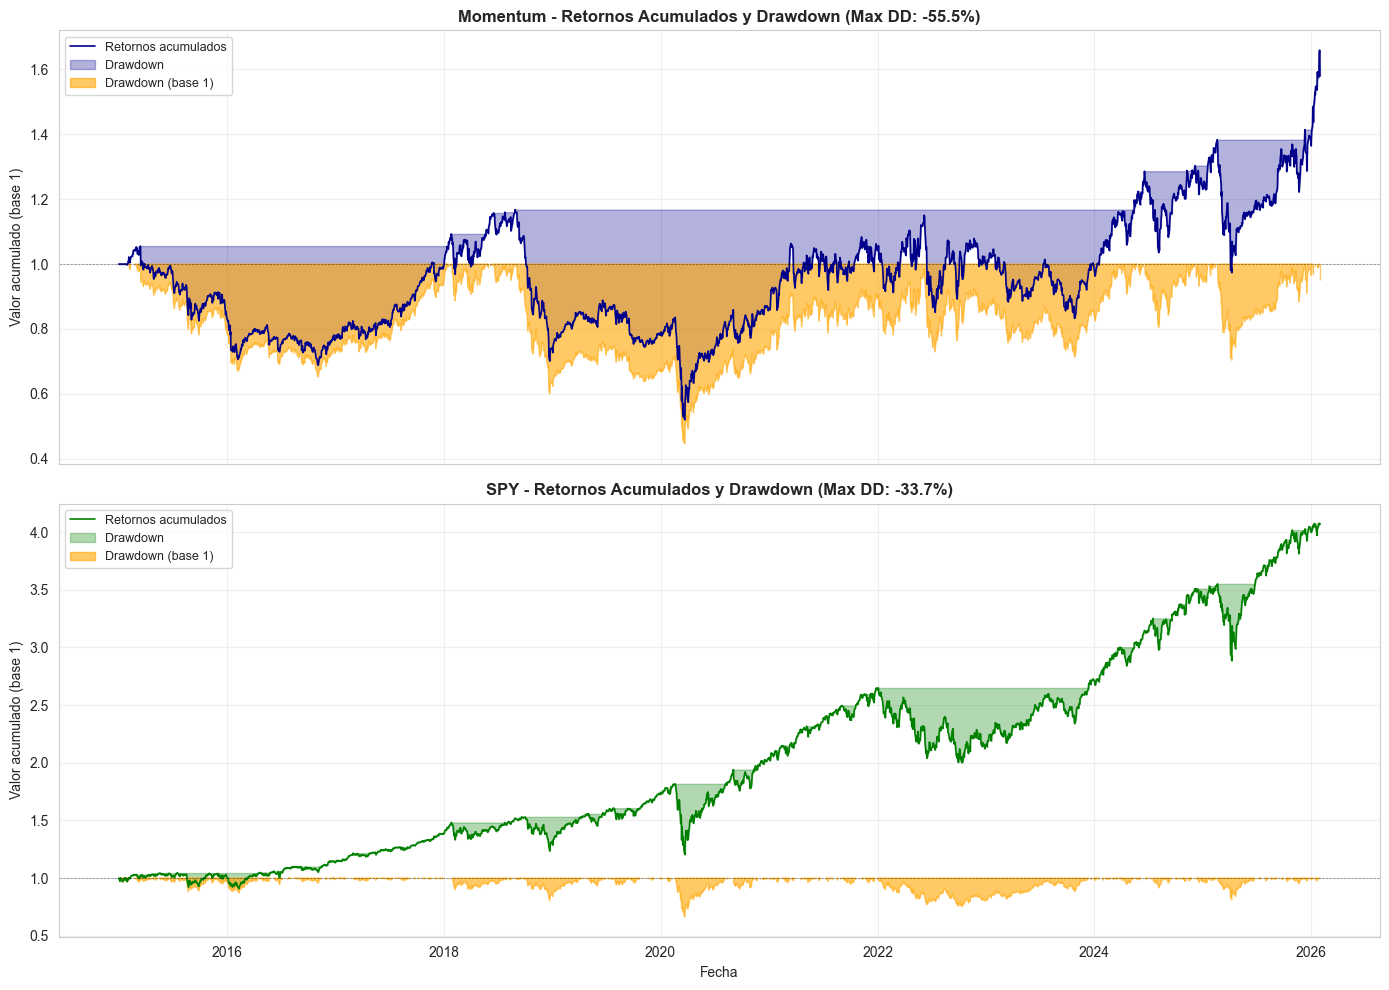

In [220]:
# Retornos acumulados (base 1) y serie de drawdown
cum_ret_algo = algo_equity / algo_equity.iloc[0]
cum_ret_spy = spy_equity / spy_equity.iloc[0]

def drawdown_series(cum_ret):
    cum_max = cum_ret.cummax()
    return (cum_ret - cum_max) / cum_max

dd_algo = drawdown_series(cum_ret_algo)
dd_spy = drawdown_series(cum_ret_spy)

# Usar la misma función que la tabla de métricas para que el Max DD del título coincida
max_dd_algo = compute_max_drawdown(algo_equity)
max_dd_spy = compute_max_drawdown(spy_equity)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, name, cum_ret, dd, max_dd, color in [
    (axes[0], 'Momentum', cum_ret_algo, dd_algo, max_dd_algo, 'darkblue'),
    (axes[1], 'SPY', cum_ret_spy, dd_spy, max_dd_spy, 'green')
]:
    cum_max = cum_ret.cummax()
    ax.plot(cum_ret.index, cum_ret, color=color, linewidth=1.2, label='Retornos acumulados')
    ax.fill_between(cum_ret.index, cum_max, cum_ret, color=color, alpha=0.3, label='Drawdown')
    ax.fill_between(cum_ret.index, 1, 1 + dd, where=(dd < 0),
                    color='orange', alpha=0.6, label='Drawdown (base 1)')
    ax.axhline(y=1, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.set_title(f'{name} - Retornos Acumulados y Drawdown (Max DD: {max_dd:.1%})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Valor acumulado (base 1)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

> <u>Comentario</u>: Los dos gráficos muestran la evolución de los retornos acumulados en base 1 y el drawdown (desviación respecto al máximo histórico y periodos por debajo del capital inicial) para la estrategia Momentum y para el SPY.
>
> - <u>Momentum</u>: La curva azul es más volátil y los drawdowns (área violeta) son más profundos y frecuentes; el máximo drawdown (ya visto en la tabla de métricas) es claramente mayor que el del SPY. La estrategia pasa mucho tiempo por debajo de 1 (área naranja): es decir, el valor acumulado en base 1 queda por debajo del nivel inicial (rentabilidad acumulada negativa, capital por debajo del punto de partida), con fases prolongadas en esa situación (p. ej. 2016–2017, 2019–2021, 2022–2024). Hacia el final del periodo se observa un repunte fuerte que lleva la serie por encima de 1,5. Esto es coherente con un entorno en el que el momentum ha funcionado mejor (en esa ventana), aunque no invalida el mayor riesgo y la peor experiencia de drawdown del resto del backtest.
>
> - <u>SPY</u>: La curva verde tiene una trayectoria más suave y alcista; el drawdown máximo  es menor que el de la estrategia. El tiempo por debajo de 1 (área naranja; es decir, con capital por debajo del nivel inicial y rentabilidad acumulada negativa) es escaso y se limita a breves episodios (años 2015-2016), lo que refleja el comportamiento típico de un buy & hold sobre el índice: menor volatilidad relativa y recuperaciones más rápidas. 
>
> En conjunto, la comparación visual refuerza el mayor riesgo y la peor experiencia de drawdown de la estrategia Momentum frente al benchmark el periodo de análisis.

### <font color=#336699>**4.3. Liquidez: picos vs retorno y riesgo posterior**</font>

Se detectan picos de liquidez de la estrategia (umbral mínimo del 5 % de cash) y se analiza qué ocurre después de cada evento en términos de retorno y riesgo relativo frente al benchmark.

Para cada pico se calcula:
- retorno forward a 1 mes y 3 meses (estrategia y SPY),
- alpha relativo (estrategia menos SPY) en esos horizontes,
- drawdown máximo forward a 3 meses para ambas series.

> <u>Nota</u>: Este bloque actúa como validación cuantitativa del análisis planteado en el Notebook 4. Allí se observó que los picos de liquidez estaban ligados a fricciones operativas de rebalanceo; aquí se comprueba qué ocurre después de esos eventos en términos de rentabilidad relativa y riesgo frente a SPY.

In [221]:
# Eventos de liquidez y comportamiento posterior (1M / 3M)
common_idx = portfolio_df.index.intersection(benchmark_df.index)
algo_eq = portfolio_df.loc[common_idx, 'equity'].astype(float)
spy_eq = benchmark_df.loc[common_idx, 'spy_equity'].astype(float)
cash_pct = (100.0 * portfolio_df.loc[common_idx, 'cash'] / algo_eq).replace([np.inf, -np.inf], np.nan).dropna()

if cash_pct.empty:
    print('No hay datos de liquidez disponibles para el análisis.')
else:
    # Excluir el primer dato para evitar el 100 % inicial del arranque.
    cash_for_peaks = cash_pct.iloc[1:] if len(cash_pct) > 1 else cash_pct.copy()

    peak_threshold = max(5.0, float(cash_for_peaks.quantile(0.90)))
    is_local_peak = (
        (cash_for_peaks >= cash_for_peaks.shift(1))
        & (cash_for_peaks > cash_for_peaks.shift(-1))
        & (cash_for_peaks >= peak_threshold)
    )
    peak_candidates = cash_for_peaks[is_local_peak].sort_values(ascending=False)

    # Evitar múltiples fechas del mismo episodio.
    selected_peaks = []
    min_separation_days = 35
    for dt, _ in peak_candidates.items():
        if all(abs((dt - prev).days) > min_separation_days for prev in selected_peaks):
            selected_peaks.append(dt)
        if len(selected_peaks) >= 8:
            break

    if not selected_peaks:
        selected_peaks = cash_for_peaks.nlargest(min(5, len(cash_for_peaks))).index.tolist()

    selected_peaks = sorted(selected_peaks)

    def _forward_return(series: pd.Series, dt: pd.Timestamp, horizon_days: int) -> float:
        pos = series.index.get_loc(dt)
        end_pos = pos + horizon_days
        if end_pos >= len(series):
            return np.nan
        return float(series.iloc[end_pos] / series.iloc[pos] - 1.0)

    def _forward_max_dd(series: pd.Series, dt: pd.Timestamp, horizon_days: int) -> float:
        pos = series.index.get_loc(dt)
        end_pos = min(pos + horizon_days, len(series) - 1)
        window = series.iloc[pos:end_pos + 1]
        if len(window) < 2:
            return np.nan
        dd = window / window.cummax() - 1.0
        return float(dd.min())

    rows = []
    for dt in selected_peaks:
        r1_algo = _forward_return(algo_eq, dt, 21)
        r3_algo = _forward_return(algo_eq, dt, 63)
        r1_spy = _forward_return(spy_eq, dt, 21)
        r3_spy = _forward_return(spy_eq, dt, 63)

        dd3_algo = _forward_max_dd(algo_eq, dt, 63)
        dd3_spy = _forward_max_dd(spy_eq, dt, 63)

        rows.append({
            'fecha_pico': dt,
            'cash_pct': float(cash_pct.loc[dt]),
            'ret_1m_algo': r1_algo,
            'ret_1m_spy': r1_spy,
            'alpha_1m': r1_algo - r1_spy if pd.notna(r1_algo) and pd.notna(r1_spy) else np.nan,
            'ret_3m_algo': r3_algo,
            'ret_3m_spy': r3_spy,
            'alpha_3m': r3_algo - r3_spy if pd.notna(r3_algo) and pd.notna(r3_spy) else np.nan,
            'max_dd_fwd_3m_algo': dd3_algo,
            'max_dd_fwd_3m_spy': dd3_spy,
            'dd_gap_3m': dd3_algo - dd3_spy if pd.notna(dd3_algo) and pd.notna(dd3_spy) else np.nan,
        })

    liquidity_followup_df = pd.DataFrame(rows).sort_values('cash_pct', ascending=False)

    print(f'Umbral de pico aplicado: {peak_threshold:.2f}% cash')
    print('Cruce de picos de liquidez con retorno y riesgo posterior:')

    display_df = liquidity_followup_df.copy()
    for col in ['cash_pct']:
        display_df[col] = display_df[col].map(lambda x: f'{x:.2f}%')
    for col in ['ret_1m_algo', 'ret_1m_spy', 'alpha_1m', 'ret_3m_algo', 'ret_3m_spy', 'alpha_3m', 'max_dd_fwd_3m_algo', 'max_dd_fwd_3m_spy', 'dd_gap_3m']:
        display_df[col] = display_df[col].map(lambda x: f'{x:.2%}' if pd.notna(x) else 'NaN')
    display(display_df)

    # Resumen agregado para lectura rápida
    summary = pd.Series({
        'media_alpha_1m': liquidity_followup_df['alpha_1m'].mean(),
        'media_alpha_3m': liquidity_followup_df['alpha_3m'].mean(),
        'media_dd_gap_3m': liquidity_followup_df['dd_gap_3m'].mean(),
        'n_eventos': len(liquidity_followup_df)
    })

    print('\nResumen promedio en eventos detectados:')
    print(f"  - Alpha medio 1M: {summary['media_alpha_1m']:.2%}")
    print(f"  - Alpha medio 3M: {summary['media_alpha_3m']:.2%}")
    print(f"  - Gap de drawdown 3M (algo - SPY): {summary['media_dd_gap_3m']:.2%}")
    print(f"  - Número de eventos: {int(summary['n_eventos'])}")

Umbral de pico aplicado: 5.00% cash
Cruce de picos de liquidez con retorno y riesgo posterior:


,fecha_pico,cash_pct,ret_1m_algo,ret_1m_spy,alpha_1m,ret_3m_algo,ret_3m_spy,alpha_3m,max_dd_fwd_3m_algo,max_dd_fwd_3m_spy,dd_gap_3m
0,2015-01-29,100.00%,5.26%,4.95%,0.31%,-4.63%,3.66%,-8.30%,-9.65%,-3.53%,-6.12%
3,2016-06-27,15.53%,6.92%,8.48%,-1.56%,2.73%,7.88%,-5.15%,-7.43%,-2.71%,-4.72%
1,2015-09-29,10.46%,9.15%,11.07%,-1.92%,3.43%,10.90%,-7.47%,-7.52%,-4.64%,-2.88%
6,2019-10-02,10.20%,1.30%,5.30%,-4.00%,4.90%,13.33%,-8.43%,-4.02%,-1.98%,-2.05%
7,2023-02-22,5.22%,-7.25%,-0.97%,-6.28%,-7.43%,4.30%,-11.73%,-12.27%,-4.72%,-7.54%
4,2017-10-02,5.15%,5.32%,1.91%,3.40%,8.81%,7.06%,1.74%,-5.88%,-1.03%,-4.85%
2,2016-02-08,5.11%,8.71%,7.53%,1.18%,12.60%,11.61%,0.99%,-2.05%,-2.44%,0.40%
5,2018-11-20,5.00%,-14.56%,-8.34%,-6.22%,-1.96%,6.45%,-8.41%,-21.03%,-15.61%,-5.42%



Resumen promedio en eventos detectados:
  - Alpha medio 1M: -1.89%
  - Alpha medio 3M: -5.84%
  - Gap de drawdown 3M (algo - SPY): -4.15%
  - Número de eventos: 8


> <u>Comentario</u>: Los resultados apuntan en la misma dirección a lo visto en el Notebook 4. El alpha medio tras los picos es negativo a 1 mes (-1.89 %) y a 3 meses (-5.84 %), y el gap de drawdown forward a 3 meses también es desfavorable para la estrategia (-4.15 %). En conjunto, la evidencia de ambos notebooks sugiere que estos repuntes de cash reflejan principalmente fricción de ejecución y no una mejora sistemática del perfil defensivo, aunque existan episodios puntuales con comportamiento más favorable.

## <font color=#0099CC>**5. TEST DE MONTE CARLO (>=25M MONOS)**</font>

### <font color=#336699>**5.1. Simulación vectorizada**</font>

Se generan al menos 25 millones de agentes aleatorios que invierten con la misma estructura que la estrategia (20 activos, 5 % cada uno, rebalanceo mensual), pero eligiendo en cada mes 20 activos al azar del universo en lugar de los 20 con mejor momentum.

Para garantizar consistencia metodológica, el universo elegible mensual se carga del Notebook 3 `universe_mask_13m.parquet`, donde ya se definió con la regla de pertenencia al S&P 500 en \(t-13..t-1\) y sin look-ahead.

In [222]:
# Test de Monte Carlo vectorizado (>=25M monos)

start_time = time.time()

# 1. Preparacion del universo y retornos mensuales

universe_mask = pd.read_parquet(DATASETS_DIR / 'universe_mask_13m.parquet')
monthly_close = pd.read_parquet(DATASETS_DIR / 'monthly_close_prices.parquet')

simple_returns_all = monthly_close.pct_change()

common = universe_mask.index.intersection(simple_returns_all.index).sort_values()

universe_mask_aligned = universe_mask.loc[common]
simple_returns_aligned = simple_returns_all.loc[common]

n_months = len(common)

# 2. Matrices densas de retornos elegibles (una por mes)

R_dense = []
size_u_per_month = np.zeros(n_months, dtype=np.int32)

for m in range(n_months):
    eligible = universe_mask_aligned.iloc[m]
    eligible_cols = eligible.index[eligible]
    rets_m = simple_returns_aligned.iloc[m][eligible_cols].dropna()
    R_dense.append(np.ascontiguousarray(rets_m.values, dtype=np.float32))
    size_u_per_month[m] = len(rets_m)

assert (size_u_per_month >= 20).all(), (
    f"Meses con menos de 20 activos elegibles (min={size_u_per_month.min()})"
)

prep_time = time.time() - start_time
print(f"> Datos preparados para Monte Carlo:")
print(f"  - Meses en comun: {n_months}")
print(
    f"  - Activos elegibles por mes (min/med/max): "
    f"{int(size_u_per_month.min())}/{int(np.median(size_u_per_month))}"
    f"/{int(size_u_per_month.max())}"
)
print("\n> Iniciando simulaciones:")

# 3. Muestreo sin reemplazo (layout transpuesto k × n_rows)

def sample_k_no_replacement(rng, n_rows, universe_size, k,
                             collision_buf, tmp_buf):
    out = rng.integers(0, universe_size, size=(k, n_rows), dtype=np.uint16)
    for i in range(1, k):
        collision_buf[:] = False
        row_i = out[i]
        for j in range(i):
            np.equal(row_i, out[j], out=tmp_buf)
            np.logical_or(collision_buf, tmp_buf, out=collision_buf)
        bad = np.where(collision_buf)[0]
        while bad.size > 0:
            out[i, bad] = rng.integers(
                0, universe_size, size=bad.size, dtype=np.uint16
            )
            sub = np.zeros(bad.size, dtype=np.bool_)
            for j in range(i):
                sub |= (out[i, bad] == out[j, bad])
            bad = bad[sub]
    return out


#4. Simulacion de 30M monos por lotes

N_MONKEYS = 30_000_000
BATCH_SIZE = 500_000
N_BATCHES = N_MONKEYS // BATCH_SIZE
K = 20
WEIGHT = np.float32(0.05)
COST_PER_MONTH = np.float32(0.0046)
ONE_F32 = np.float32(1.0)

all_terminal_equity = np.empty(N_MONKEYS, dtype=np.float32)
all_terminal_equity_nocost = np.empty(N_MONKEYS, dtype=np.float32)

collision_buf = np.empty(BATCH_SIZE, dtype=np.bool_)
tmp_buf = np.empty(BATCH_SIZE, dtype=np.bool_)
port_ret_buf = np.empty(BATCH_SIZE, dtype=np.float32)

rng = np.random.default_rng(2026)

for b in range(N_BATCHES):
    eq_cost = np.ones(BATCH_SIZE, dtype=np.float32)
    eq_nocost = np.ones(BATCH_SIZE, dtype=np.float32)

    for m in range(n_months):
        ret_u = R_dense[m]
        size_u = int(size_u_per_month[m])

        out = sample_k_no_replacement(
            rng, BATCH_SIZE, size_u, K, collision_buf, tmp_buf
        )

        port_ret_buf[:] = 0.0
        for j in range(K):
            port_ret_buf += ret_u[out[j]]
        port_ret_buf *= WEIGHT

        factor = ONE_F32 + port_ret_buf
        eq_nocost *= factor
        eq_cost *= (factor - COST_PER_MONTH)

    i0 = b * BATCH_SIZE
    i1 = i0 + BATCH_SIZE
    all_terminal_equity[i0:i1] = eq_cost * np.float32(INITIAL_CAPITAL)
    all_terminal_equity_nocost[i0:i1] = eq_nocost * np.float32(INITIAL_CAPITAL)

    if (b + 1) % 5 == 0 or b == 0:
        elapsed = time.time() - start_time
        pct = 100.0 * (b + 1) / N_BATCHES
        print(
            f"  Lote {b+1:>2}/{N_BATCHES} | "
            f"{(b+1)*BATCH_SIZE/1e6:5.1f}M monos ({pct:5.1f}%) | "
            f"{elapsed:7.1f}s"
        )

elapsed_total = time.time() - start_time
hours = elapsed_total / 3600

# 5. Resumen y persistencia

mc_summary = {
    'n_monkeys': N_MONKEYS,
    'median_equity': float(np.median(all_terminal_equity)),
    'p5_equity': float(np.percentile(all_terminal_equity, 5)),
    'p95_equity': float(np.percentile(all_terminal_equity, 95)),
    'algo_terminal_equity': float(algo_equity.iloc[-1]),
    'elapsed_seconds': elapsed_total,
}
pd.DataFrame([mc_summary]).to_csv(
    OUTPUTS_DIR / 'monte_carlo_summary.csv', index=False
)

print(f"\n> Simulacion Monte Carlo completada:")
print(f"  - Monos simulados: {N_MONKEYS:,}")
print(f"  - Tiempo total: {elapsed_total:,.1f}s ({hours:.2f} horas)")

> Datos preparados para Monte Carlo:
  - Meses en comun: 132
  - Activos elegibles por mes (min/med/max): 457/476/482

> Iniciando simulaciones:
  Lote  1/60 |   0.5M monos (  1.7%) |    18.5s
  Lote  5/60 |   2.5M monos (  8.3%) |    84.8s
  Lote 10/60 |   5.0M monos ( 16.7%) |   153.9s
  Lote 15/60 |   7.5M monos ( 25.0%) |   222.6s
  Lote 20/60 |  10.0M monos ( 33.3%) |   291.6s
  Lote 25/60 |  12.5M monos ( 41.7%) |   360.7s
  Lote 30/60 |  15.0M monos ( 50.0%) |   428.8s
  Lote 35/60 |  17.5M monos ( 58.3%) |   497.2s
  Lote 40/60 |  20.0M monos ( 66.7%) |   566.3s
  Lote 45/60 |  22.5M monos ( 75.0%) |   635.1s
  Lote 50/60 |  25.0M monos ( 83.3%) |   703.6s
  Lote 55/60 |  27.5M monos ( 91.7%) |   772.5s
  Lote 60/60 |  30.0M monos (100.0%) |   841.4s

> Simulacion Monte Carlo completada:
  - Monos simulados: 30,000,000
  - Tiempo total: 841.4s (0.23 horas)


> **Comentario:** La simulación de 30M monos usa el universo exportado por N3 y valida antes de simular que todos los meses tienen al menos 20 activos elegibles. El muestreo se realiza sin reemplazo en cada mes, de manera que cada mono mantiene 20 activos distintos por rebalanceo. La mediana del equity final de los monos y los percentiles 5 y 95 sirven de base para comparar la estrategia Momentum con la distribución de resultados de esos agentes aleatorios en la siguiente sección.

### <font color=#336699>**5.2. Evolución de rentabilidad: deciles de monos vs estrategia y SPY**</font>

Se simula una muestra de monos con trayectorias completas para representar la evolución temporal de **percentiles** cada 5 % (p5, p10, …, p95, p100) y compararlos con la estrategia Momentum y el SPY. El mejor mono (p100) se resalta en naranja.

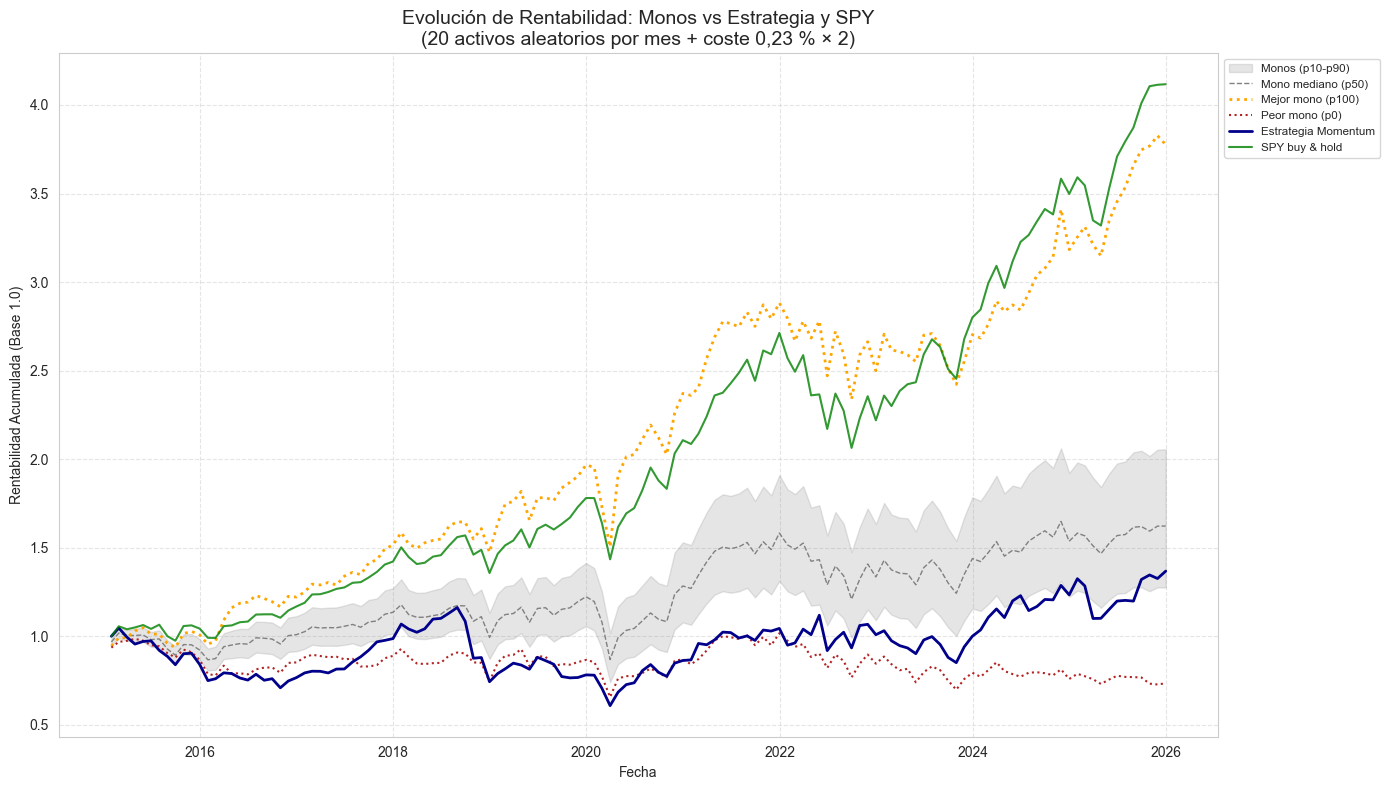

In [227]:
# Simulación ligera con trayectorias completas para gráfico (misma lógica: 20 activos aleatorios por mes, sin reemplazo).
# Se dibujan todas las trayectorias de monos (n_paths), sin límite por percentiles.

def sample_k_without_replacement_rows_local(rng, rows, universe_size, k=20):
    out = rng.integers(0, universe_size, size=(rows, k), dtype=np.uint16)
    pending = np.arange(rows, dtype=np.int64)
    while pending.size > 0:
        block = out[pending]
        dup = np.any(np.diff(np.sort(block, axis=1), axis=1) == 0, axis=1)
        if not np.any(dup):
            break
        bad = pending[dup]
        out[bad] = rng.integers(0, universe_size, size=(bad.size, k), dtype=np.uint16)
        pending = bad
    return out


n_paths = 50_000  # muestra para poder guardar evolución mensual
rng_paths = np.random.default_rng(42)
ret_paths = np.zeros((n_months, n_paths), dtype=np.float32)
cost_per_month = 0.0046

for m in range(n_months):
    size_u = int(size_u_per_month[m])
    ret_u = R_dense[m]
    indices = sample_k_without_replacement_rows_local(rng_paths, n_paths, size_u, k=20)
    ret_paths[m, :] = np.add.reduce(np.take(ret_u, indices), axis=1, dtype=np.float32) * np.float32(0.05) - np.float32(cost_per_month)

paths_cum = np.cumprod(1.0 + ret_paths, axis=0)
terminal_paths = paths_cum[-1, :]

# Mejor y peor mono para resaltar extremos
sorted_idx = np.argsort(terminal_paths)
best_mono_idx = sorted_idx[-1]
worst_mono_idx = sorted_idx[0]

# Rentabilidad acumulada estrategia y SPY (base 1.0), mismo periodo que los monos
months_index = common
algo_eq_at_months = algo_equity.reindex(months_index, method='ffill')
spy_eq_at_months = spy_equity.reindex(months_index, method='ffill')
algo_cum = algo_eq_at_months / algo_eq_at_months.iloc[0]
spy_cum = spy_eq_at_months / spy_eq_at_months.iloc[0]

plt.figure(figsize=(14, 8))
# Solo percentiles de monos (no todas las trayectorias)
p10 = np.percentile(paths_cum, 10, axis=1)
p50 = np.percentile(paths_cum, 50, axis=1)
p90 = np.percentile(paths_cum, 90, axis=1)
plt.fill_between(months_index, p10, p90, color='gray', alpha=0.2, label='Monos (p10-p90)')
plt.plot(months_index, p50, color='gray', linewidth=1, linestyle='--', label='Mono mediano (p50)')
plt.plot(months_index, paths_cum[:, best_mono_idx], color='orange', linewidth=2, linestyle=':', label='Mejor mono (p100)')
plt.plot(
    months_index,
    paths_cum[:, worst_mono_idx],
    color='firebrick',
    linewidth=1.5,
    linestyle=':',
    label='Peor mono (p0)',
)
plt.plot(months_index, algo_cum, color='darkblue', linewidth=2, label='Estrategia Momentum')
plt.plot(months_index, spy_cum, color='green', linewidth=1.5, alpha=0.8, label='SPY buy & hold')
plt.title('Evolución de Rentabilidad: Monos vs Estrategia y SPY\n'
          '(20 activos aleatorios por mes + coste 0,23 % × 2)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Rentabilidad Acumulada (Base 1.0)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> <u>Comentario</u>: La banda gris (p10–p90) y la línea gris discontinua (p50) representan la distribución de resultados de estrategias aleatorias con la misma estructura operativa (20 activos, rebalanceo mensual y coste 0,23%×2). La estrategia Momentum (azul) se mantiene gran parte del periodo en la mitad baja de esa distribución, con tramos incluso cercanos a la cola inferior, lo que sugiere ausencia de ventaja consistente frente al azar en este horizonte.
>
> El SPY (verde) muestra una trayectoria claramente superior y sostenida, situándose de forma recurrente por encima de la mediana de los monos y, en la parte final, cerca de los mejores resultados observados. Los extremos (mejor y peor mono) sirven como referencia visual de cola, pero la lectura principal debe centrarse en la posición relativa de Momentum y SPY frente al rango central (p10–p90).
>
> En conjunto, el gráfico refuerza la conclusión cuantitativa del notebook: bajo este esquema de costes y rebalanceo, la estrategia Momentum no presenta robustez frente a selección aleatoria y queda claramente por detrás del benchmark.

### <font color=#336699>**5.3. Histograma: distribución de equity final (monos vs estrategia)**</font>

Se representa la distribución de la equity final de los monos y la posición de la estrategia Momentum para visualizar su percentil.

> Estrategia: percentil 44.670330 %  |  equity final $0.40 M
> SPY (buy & hold): percentil 99.999960 %  |  equity final $1.02 M
> Mejor mono: percentil 100.000000 %  |  equity final $1.14 M


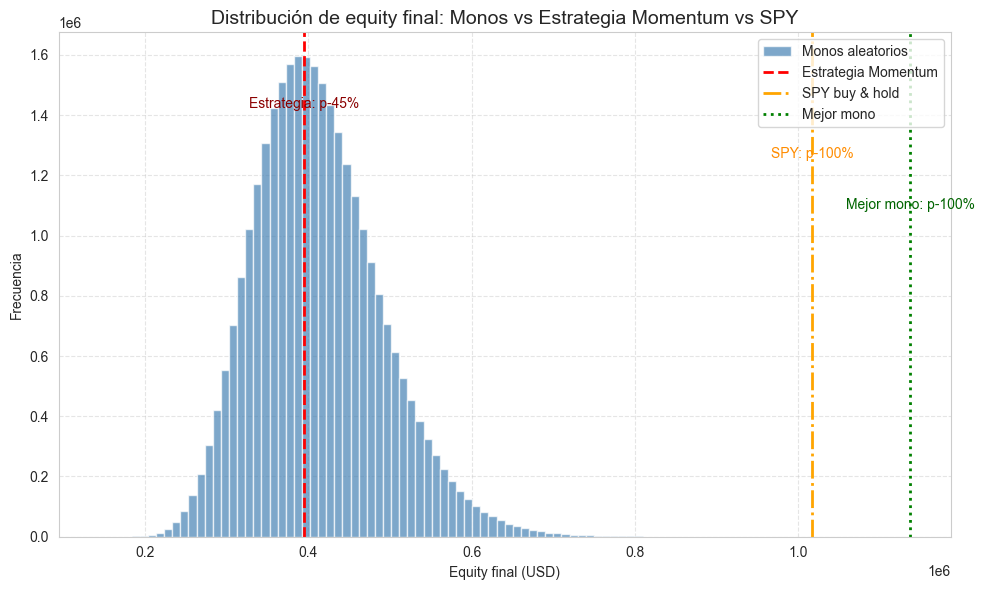

In [228]:
# 6. Comparativa de la estrategia frente a la distribución Monte Carlo

# CDF y posición de la estrategia dentro de los monos
sorted_equity = np.sort(all_terminal_equity)

def percentile_rank(values_sorted: np.ndarray, x: float) -> float:
    """Percentil empírico usando CDF por la derecha (incluye empates)."""
    rank = np.searchsorted(values_sorted, x, side='right')
    return 100.0 * rank / len(values_sorted)

algo_final = float(algo_equity.iloc[-1])
spy_final = float(spy_equity.iloc[-1])
best_mono = float(np.max(all_terminal_equity))

percentile_algo = percentile_rank(sorted_equity, algo_final)
percentile_spy = percentile_rank(sorted_equity, spy_final)
percentile_best = percentile_rank(sorted_equity, best_mono)

print(f"> Estrategia: percentil {percentile_algo:.6f} %  |  equity final ${algo_final/1e6:.2f} M")
print(f"> SPY (buy & hold): percentil {percentile_spy:.6f} %  |  equity final ${spy_final/1e6:.2f} M")
print(f"> Mejor mono: percentil {percentile_best:.6f} %  |  equity final ${best_mono/1e6:.2f} M")

plt.figure(figsize=(10, 6))
plt.hist(all_terminal_equity, bins=100, alpha=0.7, color='steelblue', edgecolor='white', label='Monos aleatorios')
plt.axvline(algo_final, color='red', linestyle='--', linewidth=2, label='Estrategia Momentum')
plt.axvline(spy_final, color='orange', linestyle='-.', linewidth=2, label='SPY buy & hold')
plt.axvline(best_mono, color='green', linestyle=':', linewidth=2, label='Mejor mono')
plt.annotate(f'Estrategia: p-{percentile_algo:.0f}%', xy=(algo_final, 0), xytext=(algo_final, plt.ylim()[1]*0.85),
             fontsize=10, ha='center', color='darkred')
plt.annotate(f'SPY: p-{percentile_spy:.0f}%', xy=(spy_final, 0), xytext=(spy_final, plt.ylim()[1]*0.75),
             fontsize=10, ha='center', color='darkorange')
plt.annotate(f'Mejor mono: p-{percentile_best:.0f}%', xy=(best_mono, 0), xytext=(best_mono, plt.ylim()[1]*0.65),
             fontsize=10, ha='center', color='darkgreen')
plt.xlabel('Equity final (USD)')
plt.ylabel('Frecuencia')
plt.title('Distribución de equity final: Monos vs Estrategia Momentum vs SPY', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> <u>Comentario</u>:  El percentil de la estrategia frente a la distribución de monos mide su posición relativa frente a trayectorias aleatorias con el mismo esquema operativo y de costes.
>
> En esta ejecución, la Estrategia Momentum queda en el percentil 44.67% (equity final ~0.40 M$): rendimiento por debajo de la mediana de los monos, aunque no en la cola más baja. El SPY buy & hold alcanza ~1.02 M$ y se sitúa en el extremo superior de la distribución, mientras que el mejor mono termina en ~1.14 M$. Con una muestra de 30 millones y percentiles de cola, SPY y mejor mono pueden aparecer muy próximos al 100.º percentil.
>
> Por tanto, la estrategia no muestra ventaja robusta frente al azar en este periodo; una fracción relevante de monos la supera. El SPY, en cambio, queda muy por encima de la distribución central de monos y cerca de la cola alta, coherente con la fuerte tendencia alcista del mercado en la muestra analizada.

### <font color=#336699>**5.4. Impacto de las comisiones en la estrategia**</font>

Se reconstruye la curva diaria **sin comisiones** de forma exacta para la operativa ejecutada: a la equity diaria con comisiones se le suma el acumulado de comisiones pagadas hasta cada fecha. Así se obtiene una comparación diaria "con comisiones" vs "sin comisiones".

> Impacto exacto de comisiones:
  - Equity final CON comisiones:    $395,006.84
  - Equity final SIN comisiones:    $482,543.03
  - Diferencia absoluta:            $87,536.18
  - Diferencia relativa sobre equity sin comisiones: 18.14 %
  - Comisiones acumuladas pagadas:  $87,536.18

> Métricas comparativas (Momentum con/sin comisiones y SPY):


,CAGR,Volatilidad,Sharpe,Sortino,Max Drawdown
Escenario,,,,,
Momentum con comisiones,0.042160,0.248696,0.291615,0.362247,-0.554557
"Momentum sin comisiones (exacto, misma operativa)",0.061163,0.207468,0.391227,0.480355,-0.467952
SPY buy & hold,0.135053,0.177453,0.804698,0.978719,-0.337173


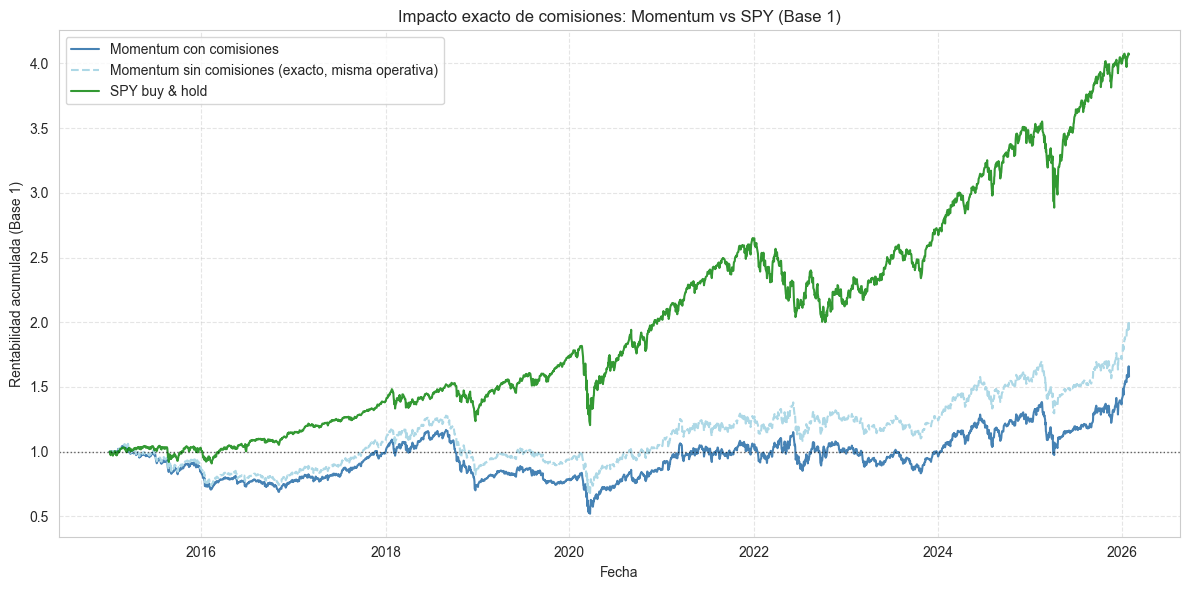

In [229]:
# Comparativa exacta (misma operativa ejecutada): estrategia con vs sin comisiones

# 1) Cargar detalle de operaciones y normalizar fechas
trades_df = pd.read_csv(OUTPUTS_DIR / 'trades_detail.csv', parse_dates=['date'])
trades_df['date'] = pd.to_datetime(trades_df['date']).dt.normalize()

# 2) Serie diaria de comisiones y acumulado
comm_daily = trades_df.groupby('date')['commission'].sum().sort_index()
comm_cum = comm_daily.cumsum()

# 3) Alinear al índice diario de equity del backtest
idx = portfolio_df.index
comm_cum_aligned = comm_cum.reindex(idx, method='ffill').fillna(0.0)

# 4) Curva exacta sin comisiones para la operativa realizada
#    (misma secuencia de operaciones; se elimina únicamente el cash-out de comisiones)
equity_with_comm = portfolio_df['equity'].astype(float)
equity_without_comm_exact = equity_with_comm + comm_cum_aligned

# 5) Resumen cuantitativo
total_comisiones = float(comm_daily.sum())
final_with_comm = float(equity_with_comm.iloc[-1])
final_without_comm = float(equity_without_comm_exact.iloc[-1])
impact_abs = final_without_comm - final_with_comm
impact_pct_on_final = 100.0 * impact_abs / final_without_comm if final_without_comm != 0 else np.nan

print('> Impacto exacto de comisiones:')
print(f'  - Equity final CON comisiones:    ${final_with_comm:,.2f}')
print(f'  - Equity final SIN comisiones:    ${final_without_comm:,.2f}')
print(f'  - Diferencia absoluta:            ${impact_abs:,.2f}')
print(f'  - Diferencia relativa sobre equity sin comisiones: {impact_pct_on_final:.2f} %')
print(f'  - Comisiones acumuladas pagadas:  ${total_comisiones:,.2f}')

# 6) Métricas comparativas (diarias)
ret_with = equity_with_comm.pct_change().dropna()
ret_without = equity_without_comm_exact.pct_change().dropna()
ret_spy_local = spy_equity.pct_change().dropna()

metrics_comm_df = pd.DataFrame(
    [
        {
            'Escenario': 'Momentum con comisiones',
            'CAGR': compute_cagr(equity_with_comm),
            'Volatilidad': compute_volatility(ret_with, freq='daily'),
            'Sharpe': compute_sharpe(ret_with, freq='daily'),
            'Sortino': compute_sortino(ret_with, freq='daily'),
            'Max Drawdown': compute_max_drawdown(equity_with_comm),
        },
        {
            'Escenario': 'Momentum sin comisiones (exacto, misma operativa)',
            'CAGR': compute_cagr(equity_without_comm_exact),
            'Volatilidad': compute_volatility(ret_without, freq='daily'),
            'Sharpe': compute_sharpe(ret_without, freq='daily'),
            'Sortino': compute_sortino(ret_without, freq='daily'),
            'Max Drawdown': compute_max_drawdown(equity_without_comm_exact),
        },
        {
            'Escenario': 'SPY buy & hold',
            'CAGR': compute_cagr(spy_equity),
            'Volatilidad': compute_volatility(ret_spy_local, freq='daily'),
            'Sharpe': compute_sharpe(ret_spy_local, freq='daily'),
            'Sortino': compute_sortino(ret_spy_local, freq='daily'),
            'Max Drawdown': compute_max_drawdown(spy_equity),
        },
    ]
).set_index('Escenario')

print('\n> Métricas comparativas (Momentum con/sin comisiones y SPY):')
display(metrics_comm_df)

# 7) Visualización en base 1 (comparación limpia entre series)
plot_df = pd.concat(
    {
        'Momentum con comisiones': equity_with_comm,
        'Momentum sin comisiones (exacto, misma operativa)': equity_without_comm_exact,
        'SPY buy & hold': spy_equity,
    },
    axis=1,
    join='inner'
).dropna()

plot_base1 = plot_df.div(plot_df.iloc[0])

plt.figure(figsize=(12, 6))
plt.plot(plot_base1.index, plot_base1['Momentum con comisiones'], label='Momentum con comisiones', color='steelblue')
plt.plot(
    plot_base1.index,
    plot_base1['Momentum sin comisiones (exacto, misma operativa)'],
    label='Momentum sin comisiones (exacto, misma operativa)',
    color='lightblue',
    linestyle='--'
)
plt.plot(plot_base1.index, plot_base1['SPY buy & hold'], label='SPY buy & hold', color='green', alpha=0.8)
plt.axhline(1.0, color='black', linestyle=':', linewidth=1, alpha=0.6)
plt.title('Impacto exacto de comisiones: Momentum vs SPY (Base 1)')
plt.xlabel('Fecha')
plt.ylabel('Rentabilidad acumulada (Base 1)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> <u>Comentario</u>: El análisis exacto muestra que el impacto de costes es material en esta estrategia. Manteniendo la misma operativa ejecutada, las comisiones acumuladas ascienden a 87,536.18 USD, lo que reduce la equity final de 482,543.03 USD (sin comisiones) a 395,006.84 USD (con comisiones). Es decir, la fricción operativa explica una pérdida de 87,536.18 USD, equivalente al 18.14% de la equity final sin costes.
>
> En términos de perfil riesgo-retorno, eliminar comisiones mejora todas las métricas de Momentum: el CAGR sube de 4.22% a 6.12%, la volatilidad baja de 24.87% a 20.75%, y mejoran Sharpe (0.29 → 0.39), Sortino (0.36 → 0.48) y Max Drawdown (-55.46% → -46.80%).
>
> Aun así, incluso en el escenario sin comisiones, la estrategia sigue claramente por detrás de SPY buy & hold en rentabilidad y eficiencia: SPY presenta CAGR 13.51%, menor volatilidad (17.75%) y mejor comportamiento ajustado por riesgo (Sharpe 0.80, Sortino 0.98, Max Drawdown -33.72%).
>
> **Conclusión**: las comisiones deterioran de forma relevante el resultado, pero no explican por sí solas toda la brecha frente al benchmark; existe además un problema de desempeño estructural de la estrategia en el periodo analizado.

### <font color=#336699>**5.5. Impacto de las comisiones en los monos**</font>

Se compara la distribución de equity final de los monos con y sin coste de rebalanceo (0,23 % x2). La simulación usa exactamente los mismos sorteos aleatorios de activos en ambos escenarios, por lo que el diferencial observado se atribuye solo al efecto de comisiones.

> Impacto de comisiones en la distribución de monos (misma muestra):
  - Delta medio por mono (sin coste - con coste): $341,964.06
  - Delta mediano por mono: $336,209.16
  - Delta relativo mediano: 45.36 %

> Tabla comparativa monos / percentiles relativos:


,Mediana equity monos,P5 monos,P95 monos,Percentil Estrategia,Percentil SPY
Escenario monos,,,,,
Con coste 0.23% x2,405007.21875,297763.28125,5.505326e+05,44.670330,99.99996
Sin coste,741216.25000,545721.75000,1.006125e+06,0.036883,95.57534


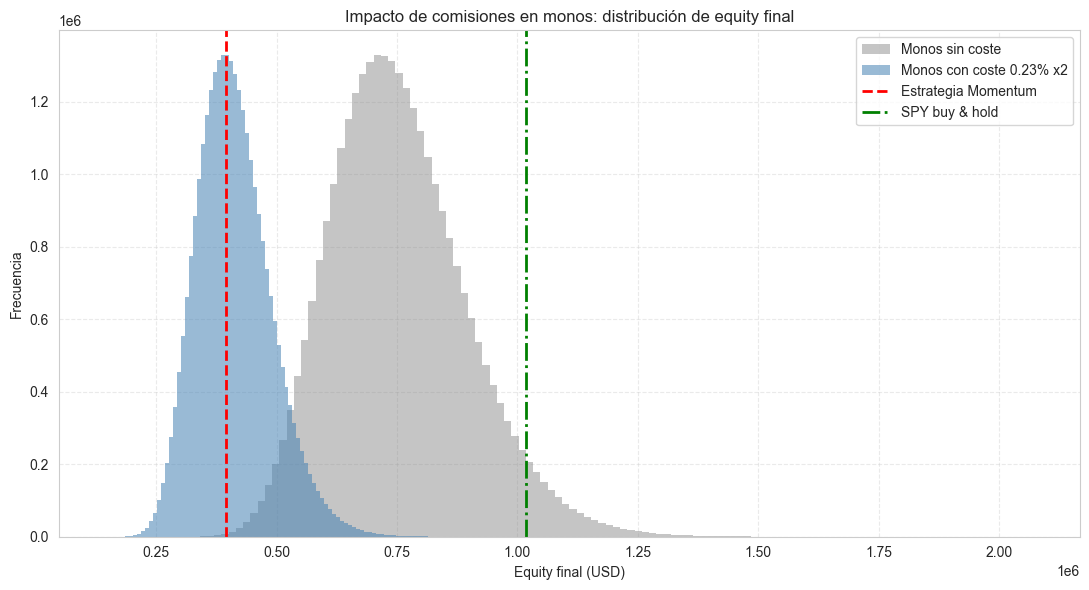

In [230]:
# Comparativa de monos: con coste vs sin coste (misma muestra aleatoria)

sorted_with_cost = np.sort(all_terminal_equity)
sorted_no_cost = np.sort(all_terminal_equity_nocost)

def percentile_rank(values_sorted: np.ndarray, x: float) -> float:
    rank = np.searchsorted(values_sorted, x, side='right')
    return 100.0 * rank / len(values_sorted)

# Percentiles de estrategia y SPY frente a cada distribución de monos
percentile_algo_with_cost = percentile_rank(sorted_with_cost, algo_final)
percentile_spy_with_cost = percentile_rank(sorted_with_cost, spy_final)
percentile_algo_no_cost = percentile_rank(sorted_no_cost, algo_final)
percentile_spy_no_cost = percentile_rank(sorted_no_cost, spy_final)

delta_monkeys = all_terminal_equity_nocost - all_terminal_equity

mc_cost_compare_df = pd.DataFrame(
    {
        'Escenario monos': ['Con coste 0.23% x2', 'Sin coste'],
        'Mediana equity monos': [
            float(np.median(all_terminal_equity)),
            float(np.median(all_terminal_equity_nocost)),
        ],
        'P5 monos': [
            float(np.percentile(all_terminal_equity, 5)),
            float(np.percentile(all_terminal_equity_nocost, 5)),
        ],
        'P95 monos': [
            float(np.percentile(all_terminal_equity, 95)),
            float(np.percentile(all_terminal_equity_nocost, 95)),
        ],
        'Percentil Estrategia': [percentile_algo_with_cost, percentile_algo_no_cost],
        'Percentil SPY': [percentile_spy_with_cost, percentile_spy_no_cost],
    }
).set_index('Escenario monos')

print('> Impacto de comisiones en la distribución de monos (misma muestra):')
print(f"  - Delta medio por mono (sin coste - con coste): ${delta_monkeys.mean():,.2f}")
print(f"  - Delta mediano por mono: ${np.median(delta_monkeys):,.2f}")
print(f"  - Delta relativo mediano: {100 * np.median(delta_monkeys / all_terminal_equity_nocost):.2f} %")
print('\n> Tabla comparativa monos / percentiles relativos:')
display(mc_cost_compare_df)

# Visualización: desplazamiento de la distribución de monos por comisiones
plt.figure(figsize=(11, 6))
plt.hist(all_terminal_equity_nocost, bins=120, alpha=0.45, color='gray', edgecolor='none', label='Monos sin coste')
plt.hist(all_terminal_equity, bins=120, alpha=0.55, color='steelblue', edgecolor='none', label='Monos con coste 0.23% x2')
plt.axvline(algo_final, color='red', linestyle='--', linewidth=2, label='Estrategia Momentum')
plt.axvline(spy_final, color='green', linestyle='-.', linewidth=2, label='SPY buy & hold')
plt.title('Impacto de comisiones en monos: distribución de equity final')
plt.xlabel('Equity final (USD)')
plt.ylabel('Frecuencia')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

> <u>Comentario</u>: Con la misma muestra aleatoria de 30M monos, las comisiones desplazan de forma material la distribución de resultados. La mediana de equity final pasa de 741,216.25 USD (sin coste) a 405,007.22 USD (con coste); de forma similar, el P5 cae de 545,721.75 a 297,763.28 USD y el P95 de 1,006,125.00 a 550,532.60 USD.
>
> El diferencial por mono es elevado: delta medio 341,964.06 USD, delta mediano 336,209.16 USD, equivalente a un 45.36 % de la equity final mediana sin costes.
>
> La posición relativa también cambia con fuerza según el benchmark de monos usado: la estrategia pasa de percentil 44.670330 % (vs monos con coste) a 0.036883 % (vs monos sin coste), y SPY de 99.999960 % a 95.575340 %. Por tanto, una parte relevante del ranking frente al azar depende de la fricción operativa del universo comparado, no solo del skill de selección.

## <font color=#0099CC>**6. CONCLUSIONES**</font>

El flujo completo de los cinco notebooks (carga -> limpieza/EDA -> señal -> ejecución -> evaluación) está bien encadenado y es metodológicamente consistente. Se han controlado los principales riesgos de backtesting (look-ahead temporal en señal y universo, alineación de fechas y separación clara entre construcción de señal y ejecución).

Con los resultados de esta ejecución, la conclusión principal se mantiene: la estrategia Momentum queda por detrás del benchmark SPY en rentabilidad y en métricas ajustadas a riesgo.

- <u>Desempeño relativo (tabla de métricas)</u>:
  - Momentum: CAGR 4.22 %, Sharpe 0.29, Sortino 0.36, Max Drawdown -55.46 %, beta 1.07 y alpha -7.98 %.
  - SPY buy & hold: CAGR 13.51 %, Sharpe 0.80, Sortino 0.98, Max Drawdown -33.72 %.
  - Lectura: mayor riesgo y peores caídas sin compensación de retorno.

- <u>Robustez frente al azar (Monte Carlo, 30M monos)</u>:
  - Simulación alineada con el universo de N3 (S&P 500 en t-13..t-1), con selección aleatoria de 20 activos sin reemplazo y coste 0.23 % x2.
  - Estrategia: percentil 44.67 % (equity final ~0.40 M USD), por debajo de la mediana de los monos.
  - SPY: en la cola superior de la distribución (~1.02 M USD), cercano al extremo alto muestral.
  - Lectura: la estrategia no muestra ventaja robusta frente al azar bajo el mismo esquema de costes.

- <u>Impacto exacto de comisiones (misma operativa ejecutada)</u>:
  - Equity final con comisiones: 395,006.84 USD.
  - Equity final sin comisiones (exacto): 482,543.03 USD.
  - Diferencia absoluta: 87,536.18 USD (18.14 % de la equity sin comisiones).
  - En métricas, sin comisiones mejora (CAGR 6.12 %, Sharpe 0.39, Sortino 0.48, MaxDD -46.80 %), pero sigue por detrás de SPY.

- <u>Impacto de comisiones en los monos (misma muestra aleatoria)</u>:
  - Mediana monos: 405,007.22 USD (con coste) vs 741,216.25 USD (sin coste); delta mediano 336,209.16 USD (45.36 %).
  - Cola izquierda/derecha: P5 = 297,763.28 vs 545,721.75 USD; P95 = 550,532.60 vs 1,006,125.00 USD.
  - Percentil Estrategia: 44.670330 % (vs monos con coste) -> 0.036883 % (vs monos sin coste).
  - Percentil SPY: 99.999960 % (vs monos con coste) -> 95.575340 % (vs monos sin coste).
  - Lectura: parte del ranking frente al azar viene de la fricción operativa del universo comparado; no todo el diferencial es skill puro de selección.

- <u>Preguntas metodológicas resueltas</u>:
  - **¿Cómo nos afecta el sesgo de supervivencia?** Puede inflar resultados al trabajar con un dataset reconstruido de componentes históricos; aunque se usan símbolos históricos/delistados, sigue siendo una limitación a vigilar.
  - **¿Cómo garantizamos que no hay look-ahead?** Señales con lag de 1 mes (hasta t-1), universo 13 meses desplazado y ejecución separada OPEN/CLOSE en el día de rebalanceo.
  - **¿Existe overfitting?** Hay riesgo, porque la estrategia usa reglas fijas sobre un único mercado/periodo; no se ha realizado validación formal walk-forward ni out-of-sample adicional por regímenes.
  - **¿El rebalanceo es irrealista?** Es una simplificación razonable para docencia, pero idealizada: no incorpora slippage, impacto de mercado, restricciones de liquidez ni fricciones intradía.
  - **¿Cuánto pagamos en comisiones?** 87,536.18 USD, con desglose entre componente variable y sobrecoste por comisión mínima.

- <u>Conclusión ejecutiva del proyecto</u>:
  - El pipeline es reproducible y técnicamente consistente con el enunciado.
  - La estrategia evaluada, con esta parametrización y estos costes, **no supera al benchmark ni en retorno ni en perfil riesgo-retorno**.
  - El siguiente paso es rediseñar para reducir turnover/coste y validar robustez con pruebas out-of-sample antes de considerar uso real.
